✅ Libraries successfully imported and environment configured!
Successfully loaded Hunters Point Ave (Stop 6) dataset spanning 1915 to 2026.

--- Hunters Point Ave Real Inflation-Adjusted Price Architecture ---
   year  nominal_fare  real_fare_2026_dollars  \
0  1915          0.05                    1.64   
1  1928          0.05                    0.97   
2  1939          0.05                    1.19   
3  1948          0.10                    1.37   
4  1953          0.15                    1.86   

                                               event  
0  7 Line Opens (Hunters Point Stop Under Constru...  
1  Hunters Point Ave Station Active (Opened Feb 1...  
2  1939 World's Fair / Long Island City Factory Peak  
3                     First Subway Fare Hike (+100%)  
4                           Subway Tokens Introduced  

--- Calculated Hunters Point Ave Arc Elasticity Metrics ---
    year                                                      event  real_fare_2026_dollars  price_elast

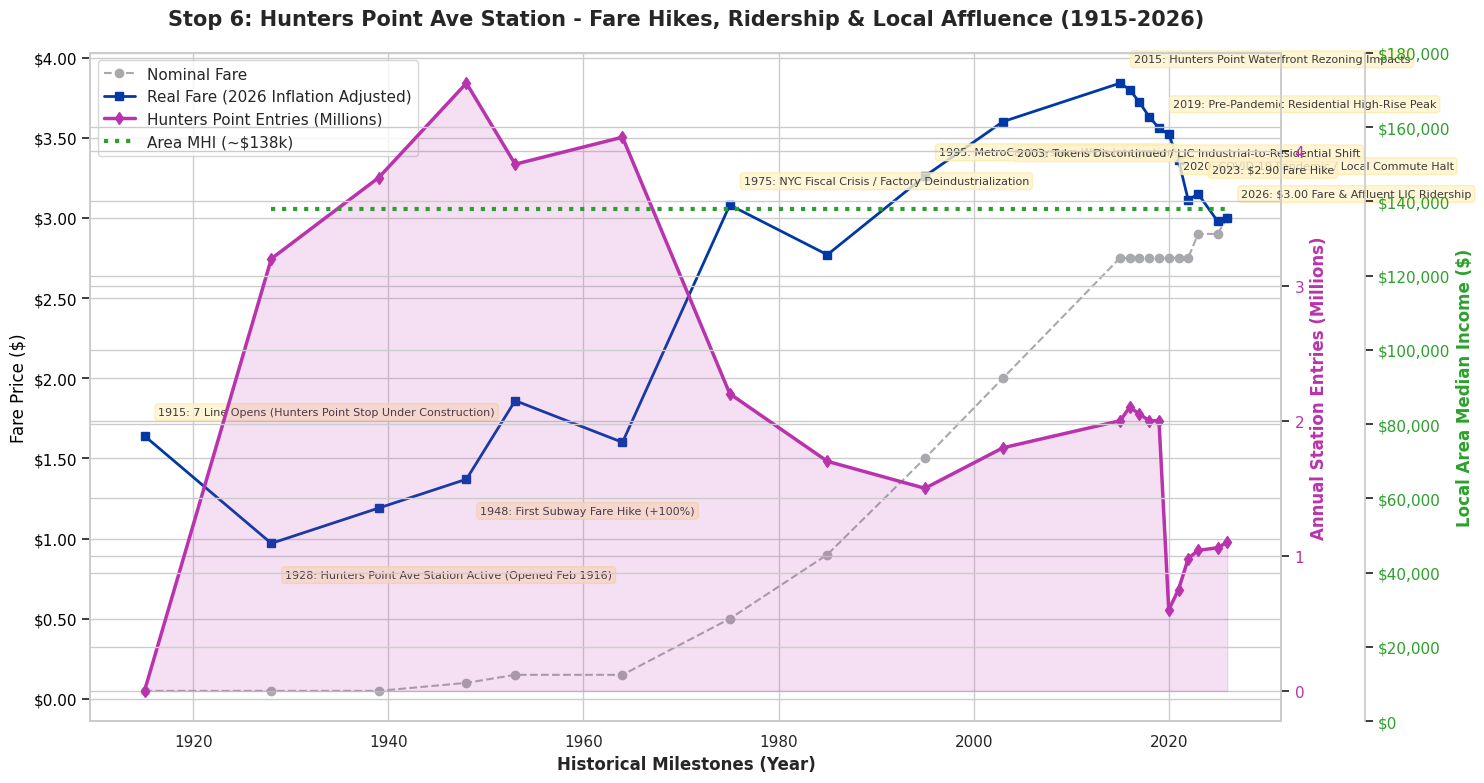

In [11]:
# ==============================================================================
# Stop 6: Hunters Point Ave Subway Fare Hikes & Ridership Elasticity (1915 - 2026)
# Featuring Historical Transit Volumes & Neighborhood Income Context
# ==============================================================================

# Install required libraries
!pip install -q pandas matplotlib seaborn requests plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime

# Set up charting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries successfully imported and environment configured!")

## Step 1: Initialize Historical Station-Specific Ridership Data (Stop 6)

raw_hunters_point_data = [
    {"year": 1915, "nominal_fare": 0.05, "annual_riders_millions": 0.0, "event": "7 Line Opens (Hunters Point Stop Under Construction)"},
    {"year": 1928, "nominal_fare": 0.05, "annual_riders_millions": 3.2, "event": "Hunters Point Ave Station Active (Opened Feb 1916)"},
    {"year": 1939, "nominal_fare": 0.05, "annual_riders_millions": 3.8, "event": "1939 World's Fair / Long Island City Factory Peak"},
    {"year": 1948, "nominal_fare": 0.10, "annual_riders_millions": 4.5, "event": "First Subway Fare Hike (+100%)"},
    {"year": 1953, "nominal_fare": 0.15, "annual_riders_millions": 3.9, "event": "Subway Tokens Introduced"},
    {"year": 1964, "nominal_fare": 0.15, "annual_riders_millions": 4.1, "event": "1964 World's Fair Queens Transit Wave"},
    {"year": 1975, "nominal_fare": 0.50, "annual_riders_millions": 2.2, "event": "NYC Fiscal Crisis / Factory Deindustrialization"},
    {"year": 1985, "nominal_fare": 0.90, "annual_riders_millions": 1.7, "event": "IRT Fleet Overhaul / Mid-80s Transition"},
    {"year": 1995, "nominal_fare": 1.50, "annual_riders_millions": 1.5, "event": "MetroCard System-Wide Integration"},
    {"year": 2003, "nominal_fare": 2.00, "annual_riders_millions": 1.8, "event": "Tokens Discontinued / LIC Industrial-to-Residential Shift"},
    {"year": 2015, "nominal_fare": 2.75, "annual_riders_millions": 2.0, "event": "Hunters Point Waterfront Rezoning Impacts"},
    {"year": 2016, "nominal_fare": 2.75, "annual_riders_millions": 2.1, "event": "Centennial Year / Tech Hub Development"},
    {"year": 2017, "nominal_fare": 2.75, "annual_riders_millions": 2.05, "event": "MTA Subway Action Plan Station Focus"},
    {"year": 2018, "nominal_fare": 2.75, "annual_riders_millions": 2.0, "event": "Steady Local Commuter Base Peak"},
    {"year": 2019, "nominal_fare": 2.75, "annual_riders_millions": 2.0, "event": "Pre-Pandemic Residential High-Rise Peak"},
    {"year": 2020, "nominal_fare": 2.75, "annual_riders_millions": 0.6, "event": "COVID-19 Pandemic / Local Commute Halt"},
    {"year": 2021, "nominal_fare": 2.75, "annual_riders_millions": 0.75, "event": "Gradual Hybrid Office Transitions"},
    {"year": 2022, "nominal_fare": 2.75, "annual_riders_millions": 0.98, "event": "Waterfront Resident Commuter Recovery"},
    {"year": 2023, "nominal_fare": 2.90, "annual_riders_millions": 1.04, "event": "$2.90 Fare Hike"},
    {"year": 2025, "nominal_fare": 2.90, "annual_riders_millions": 1.06, "event": "LIRR East Midtown Commuter Adjustments"},
    {"year": 2026, "nominal_fare": 3.00, "annual_riders_millions": 1.10, "event": "$3.00 Fare & Affluent LIC Ridership"}
]

df_hp = pd.DataFrame(raw_hunters_point_data)

# Add local neighborhood economic context (Median Household Income for Hunters Point/LIC Waterfront)
df_hp['local_median_income'] = np.where(df_hp['year'] >= 1916, 138000, np.nan)

print(f"Successfully loaded Hunters Point Ave (Stop 6) dataset spanning {df_hp['year'].min()} to {df_hp['year'].max()}.")

## Step 2: Fetch Live Macroeconomic Inflation Data (FRED API)

def fetch_cpi_data():
    """Fetches Annual CPI-U data from FRED API with automatic local fallback."""
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": "CPIAUCNS",
        "api_key": "43a00c2d68e0d4d5c96b34b73b5a79a1",
        "file_type": "json"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            obs = data['observations']
            cpi_dict = {}
            for o in obs:
                year = datetime.strptime(o['date'], '%Y-%m-%d').year
                try:
                    val = float(o['value'])
                    if year not in cpi_dict:
                        cpi_dict[year] = []
                    cpi_dict[year].append(val)
                except ValueError:
                    continue
            return {y: np.mean(v) for y, v in cpi_dict.items()}
    except Exception as e:
        print(f"FRED API access encountered an issue: {e}. Executing fallback matrices.")

    # High-precision extended fallback
    return {
        1915: 10.1, 1928: 17.1, 1939: 13.9, 1948: 24.1, 1953: 26.7,
        1964: 31.0, 1975: 53.8, 1985: 107.6, 1995: 152.4, 2003: 184.0,
        2015: 237.0, 2016: 240.0, 2017: 245.1, 2018: 251.1, 2019: 255.7,
        2020: 258.8, 2021: 271.0, 2022: 292.7, 2023: 304.7, 2025: 322.1,
        2026: 331.2
    }

cpi_map = fetch_cpi_data()
target_cpi = cpi_map.get(2026, 331.2)

# --- FIXED SECTION: Safe CPI Mapping and interpolation ---
# Create a continuous Series representing the CPI map to cleanly interpolate missing years
cpi_series = pd.Series(cpi_map).sort_index()
# Reindex to cover all years in our dataframe and interpolate any gaps cleanly
full_year_range = range(df_hp['year'].min(), df_hp['year'].max() + 1)
cpi_series = cpi_series.reindex(full_year_range).interpolate(method='linear')

# Map the interpolated CPI series back to our main DataFrame cleanly
df_hp['cpi'] = df_hp['year'].map(cpi_series)

# Calibrate nominal station pricing baseline to 2026 real value terms
df_hp['real_fare_2026_dollars'] = round(df_hp['nominal_fare'] * (target_cpi / df_hp['cpi']), 2)
print("\n--- Hunters Point Ave Real Inflation-Adjusted Price Architecture ---")
print(df_hp[['year', 'nominal_fare', 'real_fare_2026_dollars', 'event']].head())

## Step 3: Compute Price Elasticity of Demand (Ed) Timeline

df_hp['pct_chg_ridership'] = df_hp['annual_riders_millions'].pct_change()
df_hp['pct_chg_real_price'] = df_hp['real_fare_2026_dollars'].pct_change()

elasticities = [np.nan]

for i in range(1, len(df_hp)):
    q1, q2 = df_hp.loc[i-1, 'annual_riders_millions'], df_hp.loc[i, 'annual_riders_millions']
    p1, p2 = df_hp.loc[i-1, 'real_fare_2026_dollars'], df_hp.loc[i, 'real_fare_2026_dollars']

    if p1 == p2 or (q1 == 0.0 and q2 == 0.0):
        elasticities.append(0.0)
        continue

    delta_q = (q2 - q1) / ((q1 + q2) / 2)
    delta_p = (p2 - p1) / ((p1 + p2) / 2)

    arc_ed = delta_q / delta_p
    elasticities.append(round(arc_ed, 3))

df_hp['price_elasticity'] = elasticities

print("\n--- Calculated Hunters Point Ave Arc Elasticity Metrics ---")
print(df_hp[['year', 'event', 'real_fare_2026_dollars', 'price_elasticity']].to_string())

## Step 4: System Visualization Generation

fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot Real vs Nominal Fare History on primary Y axis
ax1.set_xlabel('Historical Milestones (Year)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Fare Price ($)', color='black', fontsize=12)
ax1.plot(df_hp['year'], df_hp['nominal_fare'], marker='o', label='Nominal Fare', color='#A7A9AC', linestyle='--')
ax1.plot(df_hp['year'], df_hp['real_fare_2026_dollars'], marker='s', label='Real Fare (2026 Inflation Adjusted)', color='#0039A6', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_formatter('${x:,.2f}')

# Plot Hunters Point Station Ridership Trends on secondary Y axis
ax2 = ax1.twinx()
color_hp = '#B933AD' # 7 Train Purple
ax2.set_ylabel('Annual Station Entries (Millions)', color=color_hp, fontsize=12, fontweight='bold')
ax2.fill_between(df_hp['year'], df_hp['annual_riders_millions'], alpha=0.15, color=color_hp)
ax2.plot(df_hp['year'], df_hp['annual_riders_millions'], marker='d', color=color_hp, linewidth=2.5, label='Hunters Point Entries (Millions)')
ax2.tick_params(axis='y', labelcolor=color_hp)

# Plot Local Neighborhood Income Context on a tertiary Y axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color_income = '#2CA02C' # Rich Green
ax3.set_ylabel('Local Area Median Income ($)', color=color_income, fontsize=12, fontweight='bold')
ax3.plot(df_hp['year'], df_hp['local_median_income'], color=color_income, linestyle=':', linewidth=3, label='Area MHI (~$138k)')
ax3.tick_params(axis='y', labelcolor=color_income)
ax3.yaxis.set_major_formatter('${x:,.0f}')
ax3.set_ylim(0, 180000)

# Overlay Key Station-Specific Annotations
for i, row in df_hp.iterrows():
    if row['year'] in [1915, 1928, 1948, 1975, 1995, 2003, 2015, 2019, 2020, 2023, 2026]:
        ax1.annotate(f"{row['year']}: {row['event']}",
                     (row['year'], row['real_fare_2026_dollars']),
                     textcoords="offset points",
                     xytext=(10, 15 if i%2==0 else -25),
                     ha='left', fontsize=8, alpha=0.9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="#FFF3CD", alpha=0.8, ec="#FFEBAA"))

# Compile legends from all three independent axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.title("Stop 6: Hunters Point Ave Station - Fare Hikes, Ridership & Local Affluence (1915-2026)", fontsize=15, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()